Выполнил: **Окунев Никита Дмитриевич**, группа **P3122**

# Подготовка

## Установка библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import warnings
warnings.filterwarnings("ignore")

## Загрузка датасетов

In [ ]:
!wget https://raw.githubusercontent.com/rebeccabilbro/titanic/refs/heads/master/data/train.csv

--2026-05-21 14:24:21--  https://raw.githubusercontent.com/rebeccabilbro/titanic/refs/heads/master/data/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60301 (59K) [text/plain]
Saving to: ‘train.csv.1’

train.csv.1         100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2026-05-21 14:24:22 (3.96 MB/s) - ‘train.csv.1’ saved [60301/60301]



# 1. первичный анализ данных

## 1.1. Загрузить данные из CSV-файла

In [ ]:
train = pd.read_csv('train.csv')

## 1.2. Вывести первые 10 строк дата-фрейма

In [ ]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 1.3. Проверить типы данных каждого столбца

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 1.4. Определить количество пропусков в каждом столбце

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Пропуски:  
- Age - 177 пропусков  
- Cabin - 687 пропусков  
- Embarked - 2 пропуска

## 1.5. Получить статистические характеристики числовых признаков

In [ ]:
numerical_features = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
for feature in numerical_features:
  print(f'STATS FOR {feature}:')
  print(f"min = {train[feature].min()}")
  print(f"max = {train[feature].max()}")
  print(f"median = {train[feature].median()}")
  print(f"mean = {train[feature].mean()}")

STATS FOR PassengerId:
min = 1
max = 891
median = 446.0
mean = 446.0
STATS FOR Survived:
min = 0
max = 1
median = 0.0
mean = 0.3838383838383838
STATS FOR Pclass:
min = 1
max = 3
median = 3.0
mean = 2.308641975308642
STATS FOR Age:
min = 0.42
max = 80.0
median = 28.0
mean = 29.69911764705882
STATS FOR SibSp:
min = 0
max = 8
median = 0.0
mean = 0.5230078563411896
STATS FOR Parch:
min = 0
max = 6
median = 0.0
mean = 0.38159371492704824
STATS FOR Fare:
min = 0.0
max = 512.3292
median = 14.4542
mean = 32.204207968574636


## 1.6. Построить гистограммы распределения для числовых признаков

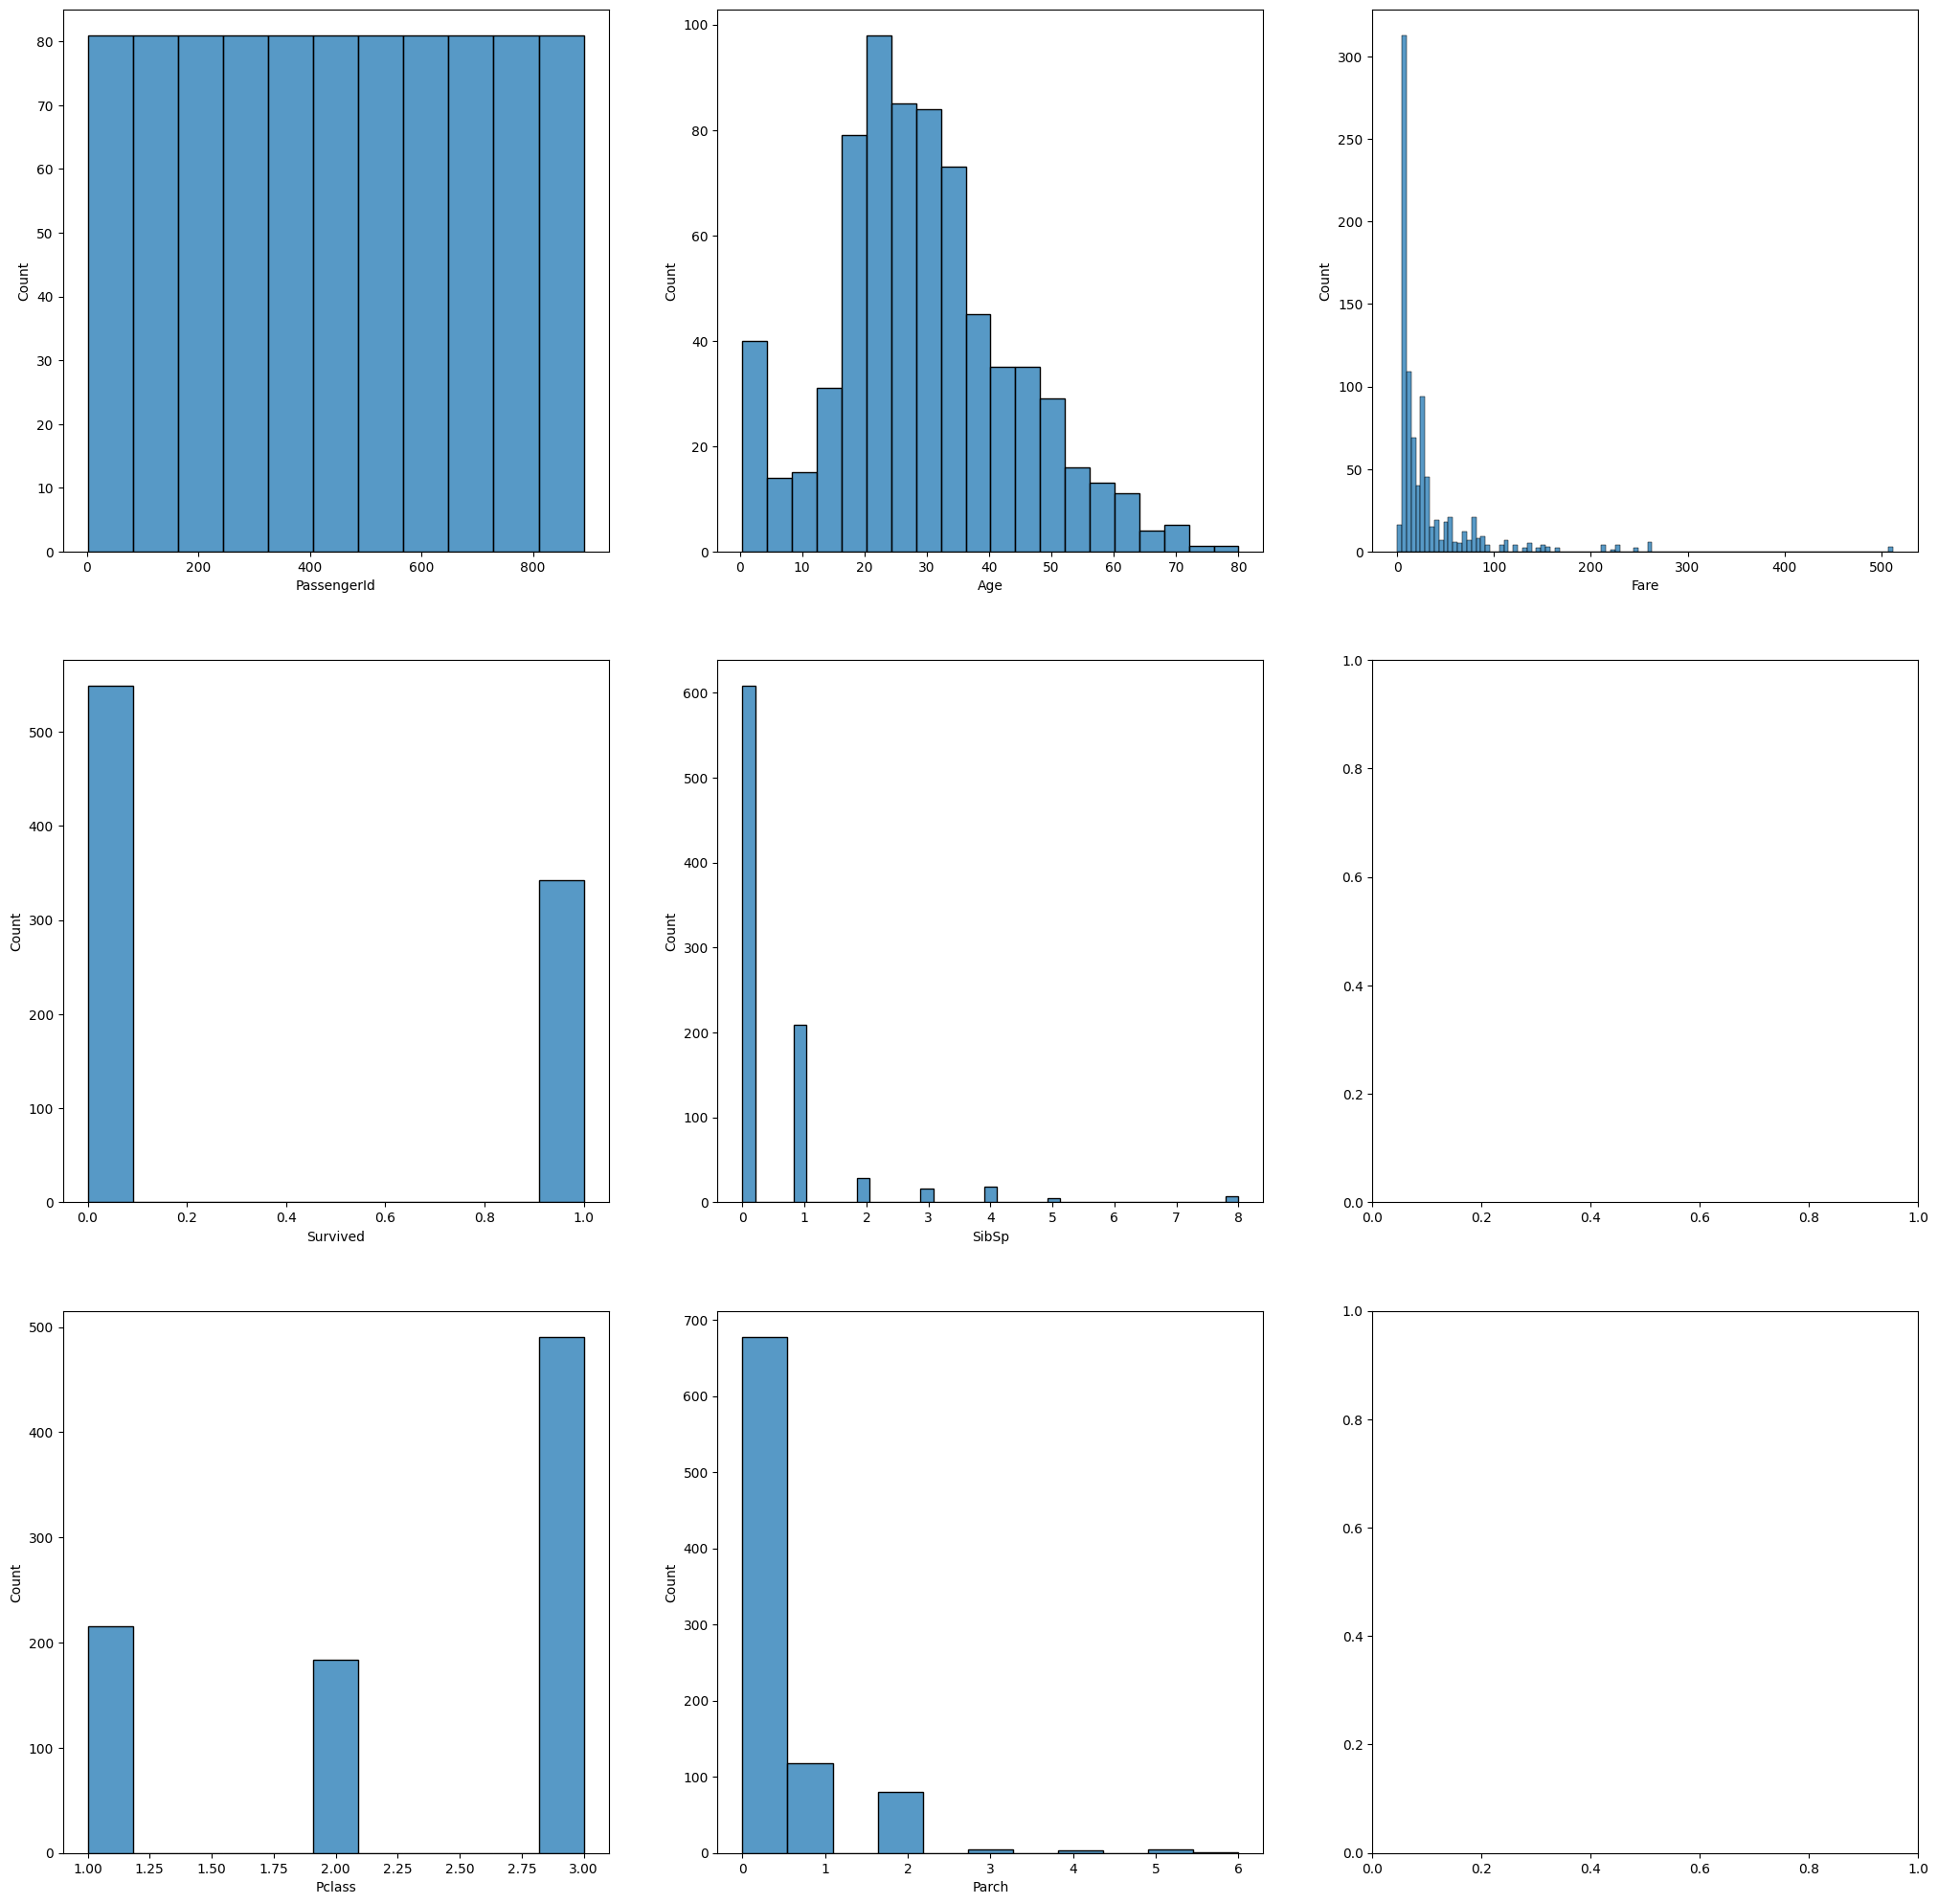

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(25, 25))
#axes = axes.flatten()

count = 0
for column in numerical_features:
    x, y = count % 3, count // 3
    sns.histplot(train[column], ax=axes[x, y])
    count += 1

*понятия не имею, почему в (1, 2) пропуск*

# 2. Обработка пропусков

## 2.1. Определить столбцы с пропусками

*Ранее мы уже нашли пропуски в столбцах, но на всякий случай перепроверим все уникальные значения в столбцах*

In [ ]:
for column in train.columns:
  if column not in ['PassengerId', 'Name', 'Ticket']:
    print(column, train[column].unique())

Survived [0 1]
Pclass [3 1 2]
Sex ['male' 'female']
Age [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]
SibSp [1 0 3 4 2 5 8]
Parch [0 1 2 5 3 4 6]
Fare [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   9.475   21.      41.5792  15.5     21.6792  17.8
  39.6875   7.

*Теперь мы знаем, что нет скрытых пропусков типа unknown*

Столбцы с пропусками (были найдены в задаче 1.4):  
- Age - 177 пропусков  
- Cabin - 687 пропусков  
- Embarked - 2 пропуска

## 2.2. Для столбца Age:  
1. Посчитать медианное значение
2. Заполнить пропуски медианным значением
3. Создать новый признак Age_group на основе заполненного возраста

In [ ]:
train['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [ ]:
med = train['Age'].median()
print(f'Медианное значение признака Age: {med}')
train['Age'] = train['Age'].fillna(med)
train['Age'].unique()

Медианное значение признака Age: 28.0


array([22.  , 38.  , 26.  , 35.  , 28.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  ,  8.  ,
       19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  ,
       29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 ,
       20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  , 60.  ,
       10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,
       24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [ ]:
groups = [0] * 5  # [0, 16], [16, 24], [24, 60], [60, 100], Nan's

for age in train['Age']:
  if age > 60:  # пожилые
    groups[3] += 1
  elif 60 >= age > 24:  # обычные
    groups[2] += 1
  elif 24 >= age > 16:  # молодежь
    groups[1] += 1
  elif 16 >= age > 0:  # дети
    groups[0] += 1
  else:  # пропуски
    groups[4] += 1
groups

[100, 177, 592, 22, 0]

In [ ]:
train['Age_group'] = [0] * len(train)
for i in range(len(train)):
  age = train.iloc[i]['Age']
  if age > 60:  # пожилые
    groups[3] += 1
    train.loc[i, 'Age_group'] = 3

  elif 60 >= age > 24:  # обычные
    groups[2] += 1
    train.loc[i, 'Age_group'] = 2

  elif 24 >= age > 16:  # молодежь
    groups[1] += 1
    train.loc[i, 'Age_group'] = 1

  elif 16 >= age > 0:  # дети
    groups[0] += 1
    train.loc[i, 'Age_group'] = 0

## 2.3. Для столбца Embarked:
1. Определить наиболее часто встречающееся значение
2. Заполнить пропуски модой


In [ ]:
embarked_mode = train['Embarked'].mode()[0]
print(f'Наиболее встречающееся значение в Embarked: {embarked_mode}')
train['Embarked'] = train['Embarked'].fillna(embarked_mode)
train['Embarked'].unique()

Наиболее встречающееся значение в Embarked: S


array(['S', 'C', 'Q'], dtype=object)

## 2.4. Для столбца Cabin  
1. Рассмотреть возможность удаления или создания нового признака на основе первой буквы
Изменим столбец следующим образом:
NaN -

In [ ]:
print(set([a[0] for a in train['Cabin'].unique()[1:]]))  # смотрим все первые буквы

{'C', 'D', 'T', 'F', 'G', 'A', 'E', 'B'}


In [ ]:
cabin_mapper = {'A': 1,
                'B': 2,
                'C': 3,
                'D': 4,
                'E': 5,
                'F': 6,
                'G': 7,
                'T': 8}


train['Cabin'] = (
    train['Cabin']
    .str[0]          # берём первую букву
    .map(cabin_mapper)  # заменяем букву на число
    .fillna(0)       # NaN меняем на нули
    .astype(int)     # приводим к int (он почему-то делает float-ом)
)

In [ ]:
print(train['Cabin'].unique())

[0 3 5 7 4 1 2 6 8]


# 3. Работа с типами данных

## 3.1. Преобразовать Pclass в категориальный тип строкового значения (из числового - в строковое: 1 - F, 2 - S, 3 - T )

In [ ]:
train['Pclass'] = train['Pclass'].map({1: 'F', 2: 'S', 3: 'T'})  # замены

In [ ]:
train['Pclass'].unique()

array(['T', 'F', 'S'], dtype=object)

## 3.2. Создать новый признак Title из столбца Name (мистер, миссис и т.д.)  
(+) Удаление Title из столбца Name

In [ ]:
train['Title'] = ['N/A'] * len(train)  # заполняем пустыми значениями


for i in range(len(train)): # проходимся по данным
  name = train.iloc[i]['Name']  # получаем имя i-го человека
  words = name.split()  # разбиваем имя на слова
  for word in words:  # проходимся по каждому слову
    if len(word) != 0 and word[-1] == '.':
      social_rank = word
      break

  train.loc[i, 'Title'] = social_rank  # заполняем новую фичу
  train.loc[i, 'Name'] = name.replace(social_rank + ' ', '')  # чистим старую фичу

In [ ]:
train['Title'].unique()  # узнать все титулы

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Don.', 'Rev.', 'Dr.', 'Mme.',
       'Ms.', 'Major.', 'Lady.', 'Sir.', 'Mlle.', 'Col.', 'Capt.',
       'Countess.', 'Jonkheer.'], dtype=object)

In [ ]:
train.head(10)  # Проверим, как это выглядит

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Title
0,1,0,T,"Braund, Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S,1,Mr.
1,2,1,F,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,3,C,2,Mrs.
2,3,1,T,"Heikkinen, Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S,2,Miss.
3,4,1,F,"Futrelle, Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,3,S,2,Mrs.
4,5,0,T,"Allen, William Henry",male,35.0,0,0,373450,8.0500,0,S,2,Mr.
5,6,0,T,"Moran, James",male,28.0,0,0,330877,8.4583,0,Q,2,Mr.
6,7,0,F,"McCarthy, Timothy J",male,54.0,0,0,17463,51.8625,5,S,2,Mr.
7,8,0,T,"Palsson, Gosta Leonard",male,2.0,3,1,349909,21.0750,0,S,0,Master.
8,9,1,T,"Johnson, Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,0,S,2,Mrs.
9,10,1,S,"Nasser, Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,0,C,0,Mrs.


## 3.3. Преобразовать Sex в числовой формат (0/1)

In [ ]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})  # замены
train['Sex'].unique()

array([0, 1])

## 3.4. Создать признак FamilySize = SibSp + Parch + 1<br>3.5. Создать признак IsAlone (1 если FamilySize = 1, иначе 0)


In [ ]:
train['FamilySize'] = [1] * len(train)
train['IsAlone'] = [0] * len(train)
for i in range(len(train)): # проходимся по данным
  SibSp = train.iloc[i]['SibSp']  # получаем SibSp i-го человека
  Parch = train.iloc[i]['Parch']  # получаем Parch i-го человека
  train.loc[i, 'FamilySize'] += SibSp + Parch  # считаем размер семьи
  if SibSp == Parch == 0:
    train.loc[i, 'IsAlone'] = 1
train['FamilySize'].unique()

array([ 2,  1,  5,  3,  7,  6,  4,  8, 11])

# 4. Удаление выбросов

## 4.1. Построить boxplot для признака Fare

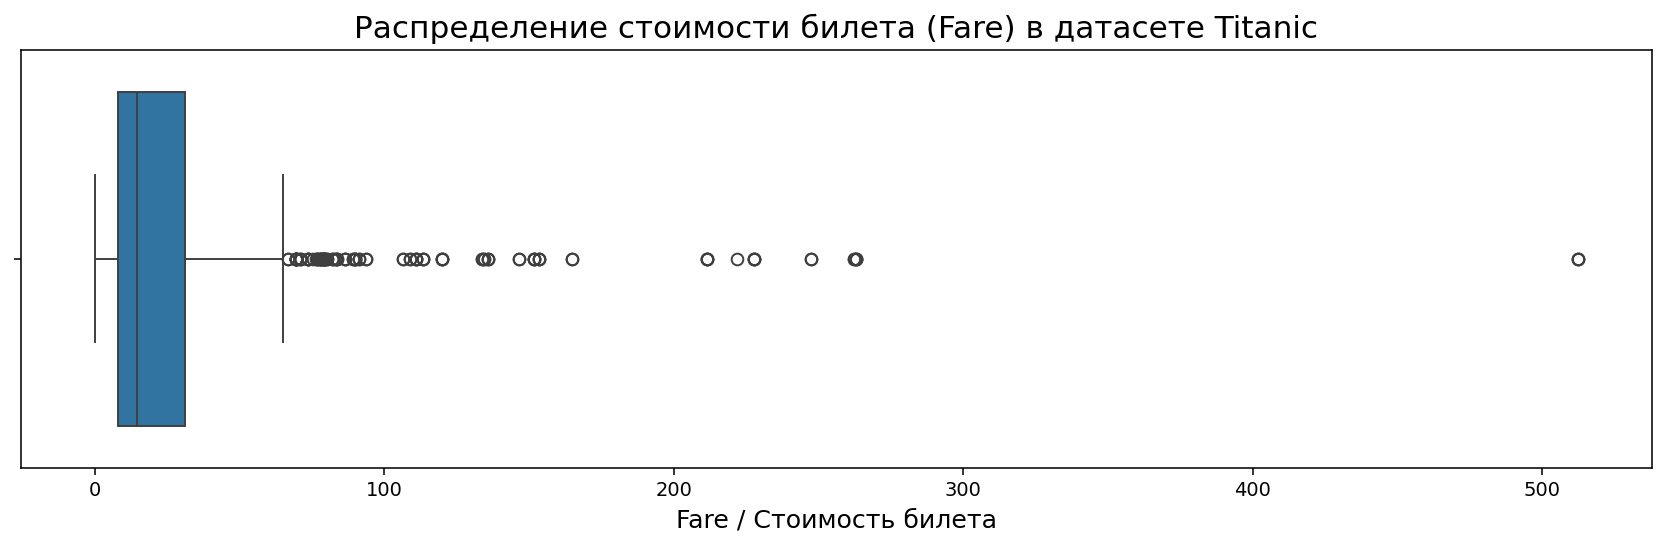

In [ ]:
plt.figure(figsize=(12, 4), dpi=140)

ax = sns.boxplot(
    data=train,
    x="Fare"
)

ax.set_title(
    "Распределение стоимости билета (Fare) в датасете Titanic",
    fontsize=16
)

ax.set_xlabel("Fare / Стоимость билета", fontsize=13)

plt.tight_layout()
plt.show()

## 4.2. Определить выбросы с помощью IQR-метода

In [ ]:
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[(train['Fare'] < lower_bound) | (train['Fare'] > upper_bound)]
print(lower_bound, upper_bound)  # но фактически в нижней границе нет смысла
outliers.head(10)

-26.724 65.6344


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Title,FamilySize,IsAlone
1,2,1,F,"Cumings, John Bradley (Florence Briggs Thayer)",1,38.0,1,0,PC 17599,71.2833,3,C,2,Mrs.,2,0
27,28,0,F,"Fortune, Charles Alexander",0,19.0,3,2,19950,263.0000,3,S,1,Mr.,6,0
31,32,1,F,"Spencer, William Augustus (Marie Eugenie)",1,28.0,1,0,PC 17569,146.5208,2,C,2,Mrs.,2,0
34,35,0,F,"Meyer, Edgar Joseph",0,28.0,1,0,PC 17604,82.1708,0,C,2,Mr.,2,0
52,53,1,F,"Harper, Henry Sleeper (Myna Haxtun)",1,49.0,1,0,PC 17572,76.7292,4,C,2,Mrs.,2,0
61,62,1,F,"Icard, Amelie",1,38.0,0,0,113572,80.0000,2,S,2,Miss.,1,1
62,63,0,F,"Harris, Henry Birkhardt",0,45.0,1,0,36973,83.4750,3,S,2,Mr.,2,0
72,73,0,S,"Hood, Ambrose Jr",0,21.0,0,0,S.O.C. 14879,73.5000,0,S,1,Mr.,1,1
88,89,1,F,"Fortune, Mabel Helen",1,23.0,3,2,19950,263.0000,3,S,1,Miss.,6,0
102,103,0,F,"White, Richard Frasar",0,21.0,0,1,35281,77.2875,4,S,1,Mr.,2,0


## 4.3. Визуализировать распределение Age

In [ ]:
print(min(train['Age']), max(train['Age']))

0.42 80.0


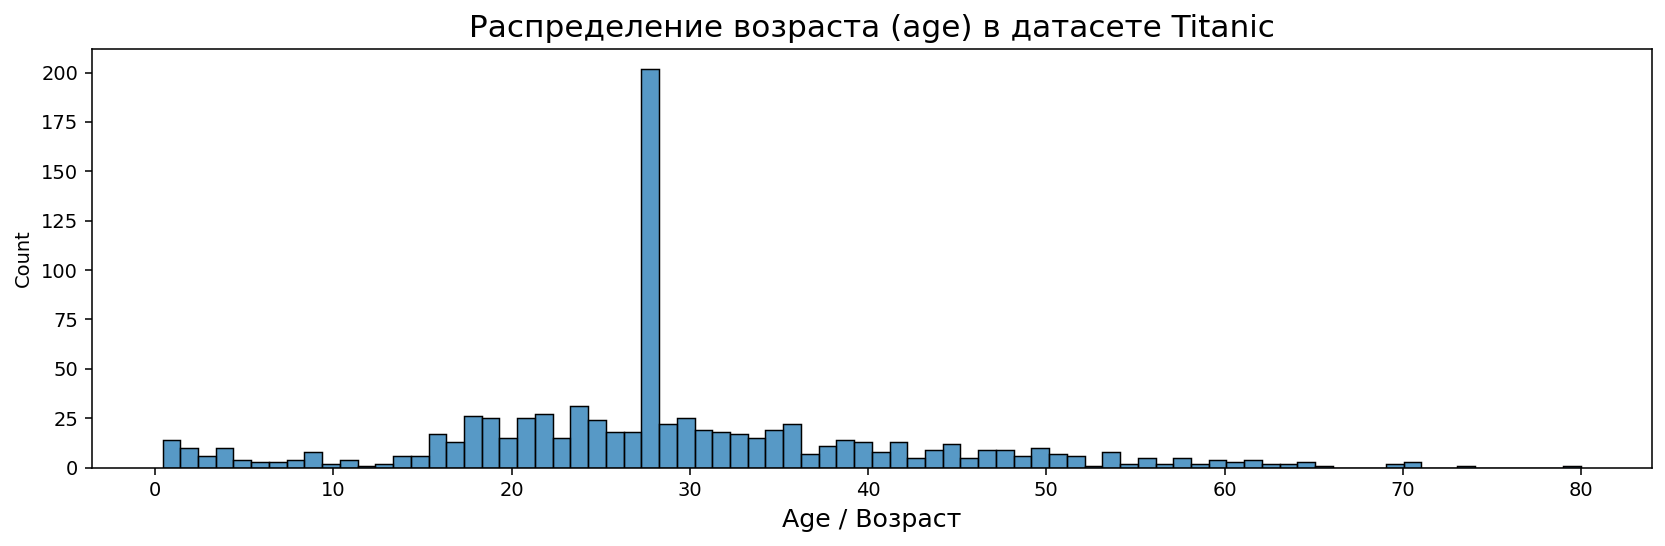

In [ ]:
plt.figure(figsize=(12, 4), dpi=140)

ax = sns.histplot(
    data=train,
    x="Age",
    bins=80
)

ax.set_title(
    "Распределение возраста (age) в датасете Titanic",
    fontsize=16
)

ax.set_xlabel("Age / Возраст", fontsize=13)

plt.tight_layout()
plt.show()

## 4.4. Применить winsorization для признака Fare

In [ ]:
# Применим IQR-метод:
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train['Fare'] = train['Fare'].clip(lower=lower_bound, upper=upper_bound)
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Title,FamilySize,IsAlone
0,1,0,T,"Braund, Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,S,1,Mr.,2,0
1,2,1,F,"Cumings, John Bradley (Florence Briggs Thayer)",1,38.0,1,0,PC 17599,65.6344,3,C,2,Mrs.,2,0
2,3,1,T,"Heikkinen, Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,S,2,Miss.,1,1
3,4,1,F,"Futrelle, Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,3,S,2,Mrs.,2,0
4,5,0,T,"Allen, William Henry",0,35.0,0,0,373450,8.0500,0,S,2,Mr.,1,1
5,6,0,T,"Moran, James",0,28.0,0,0,330877,8.4583,0,Q,2,Mr.,1,1
6,7,0,F,"McCarthy, Timothy J",0,54.0,0,0,17463,51.8625,5,S,2,Mr.,1,1
7,8,0,T,"Palsson, Gosta Leonard",0,2.0,3,1,349909,21.0750,0,S,0,Master.,5,0
8,9,1,T,"Johnson, Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,0,S,2,Mrs.,3,0
9,10,1,S,"Nasser, Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,0,C,0,Mrs.,2,0


## 4.5. Заменить экстремальные значения на 95-й перцентиль (для Age)

In [ ]:
Q95 = train['Age'].quantile(0.95)
train['Age'] = train['Age'].clip(upper=Q95)
print(Q95)
train.head(10)

54.0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Title,FamilySize,IsAlone
0,1,0,T,"Braund, Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,S,1,Mr.,2,0
1,2,1,F,"Cumings, John Bradley (Florence Briggs Thayer)",1,38.0,1,0,PC 17599,65.6344,3,C,2,Mrs.,2,0
2,3,1,T,"Heikkinen, Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,S,2,Miss.,1,1
3,4,1,F,"Futrelle, Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,3,S,2,Mrs.,2,0
4,5,0,T,"Allen, William Henry",0,35.0,0,0,373450,8.0500,0,S,2,Mr.,1,1
5,6,0,T,"Moran, James",0,28.0,0,0,330877,8.4583,0,Q,2,Mr.,1,1
6,7,0,F,"McCarthy, Timothy J",0,54.0,0,0,17463,51.8625,5,S,2,Mr.,1,1
7,8,0,T,"Palsson, Gosta Leonard",0,2.0,3,1,349909,21.0750,0,S,0,Master.,5,0
8,9,1,T,"Johnson, Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,0,S,2,Mrs.,3,0
9,10,1,S,"Nasser, Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,0,C,0,Mrs.,2,0


# 5. Агрегация данных

## 5.1. Посчитать среднее выживание по классам<br>(буду считать, что "классом" является Pclass)

In [ ]:
train['Pclass'].unique()

array(['T', 'F', 'S'], dtype=object)

In [ ]:
Tclass_train = train[train['Pclass'] == 'T']
Fclass_train = train[train['Pclass'] == 'F']
Sclass_train = train[train['Pclass'] == 'S']

classes = [Tclass_train, Fclass_train, Sclass_train]

i = 1
for single_class in classes:
  average = single_class['Survived'].mean()
  print(f'Survival of {'T' if i == 1 else ('F' if i == 2 else 'S')}-class: {average.round(2)}')
  i += 1

Survival of T-class: 0.24
Survival of F-class: 0.63
Survival of S-class: 0.47


## 5.2. Группировать данные по Pclass и Sex

In [ ]:
train_grouped = train.groupby(['Pclass', 'Sex'])
train_grouped

## 5.3. Посчитать медианный возраст по портам посадки

In [ ]:
train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
"""
Это столбец Embarked
S = Southampton
C = Cherbourg
Q = Queenstown

"""
train_embarked = train.groupby('Embarked')
train_embarked['Age'].mean()

,Age
Embarked,
C,29.731667
Q,27.636364
S,28.950851


## 5.4. Создать сводную таблицу выживаемости по новым признакам

1. Столбец Age_Group

In [ ]:
train_age_group = train.groupby('Age_group')
train_age_group['Survived'].mean().round(2)

,Survived
Age_group,
0,0.55
1,0.36
2,0.37
3,0.23


2. Столбец Cabin

In [ ]:
train_cabin = train.groupby('Cabin')
train_cabin['Survived'].mean().round(2)

,Survived
Cabin,
0,0.30
1,0.47
2,0.74
3,0.59
4,0.76
5,0.75
6,0.62
7,0.50
8,0.00


3. Столбец Pclass

In [ ]:
train_pclass = train.groupby('Pclass')
train_pclass['Survived'].mean().round(2)

,Survived
Pclass,
F,0.63
S,0.47
T,0.24


4. Столбец Title

In [ ]:
train_title = train.groupby('Title')
train_title['Survived'].mean().round(2)

,Survived
Title,
Capt.,0.00
Col.,0.50
Countess.,1.00
Don.,0.00
Dr.,0.43
Jonkheer.,0.00
Lady.,1.00
Major.,0.50
Master.,0.57


5. Столбец Sex

In [ ]:
train_sex = train.groupby('Sex')
train_sex['Survived'].mean().round(2)

,Survived
Sex,
0,0.19
1,0.74


6. Столбец FamilySize

In [ ]:
train_familysize = train.groupby('FamilySize')
train_familysize['Survived'].mean().round(2)

,Survived
FamilySize,
1,0.30
2,0.55
3,0.58
4,0.72
5,0.20
6,0.14
7,0.33
8,0.00
11,0.00


7. Столбец IsAlone

In [ ]:
train_isalone = train.groupby('IsAlone')
train_isalone['Survived'].mean().round(2)

,Survived
IsAlone,
0,0.51
1,0.30


## 5.5. Сохранить очищенные данные в новый CSV-файл

In [ ]:
train.to_csv('Titanic_dataset_train_cleaned.csv')

# 6. Вычислить метрики качества очистки данных

## 6.1. Процент заполненных пропусков
Столбцы с пропусками (до очистки):
- Age - 177 пропусков  
- Cabin - 687 пропусков  
- Embarked - 2 пропуска

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    int64  
 11  Embarked     891 non-null    object 
 12  Age_group    891 non-null    int64  
 13  Title        891 non-null    object 
 14  FamilySize   891 non-null    int64  
 15  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(9), object(5)
memory usage: 111.5+ KB


In [ ]:
train['Age'].unique()

array([22.  , 38.  , 26.  , 35.  , 28.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 20.  , 39.  , 31.  , 34.  , 15.  ,  8.  , 19.  , 40.  ,
       42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  , 29.  , 28.5 ,  5.  ,
       11.  , 45.  , 17.  , 32.  , 16.  , 25.  ,  0.83, 30.  , 33.  ,
       23.  , 24.  , 46.  , 37.  , 47.  , 14.5 , 32.5 , 12.  ,  9.  ,
       36.5 , 51.  , 40.5 , 44.  ,  1.  , 50.  , 36.  , 45.5 , 20.5 ,
       41.  , 52.  , 23.5 ,  0.92, 43.  , 10.  , 13.  , 48.  ,  0.75,
       53.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 ])

В столбце Age не осталось пропусков

In [ ]:
train['Cabin'].unique()

array([0, 3, 5, 7, 4, 1, 2, 6, 8])

В столбце Cabin не осталось пропусков

In [ ]:
train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

В столбце Embarked не осталось пропусков

Значит процент заполненных пропусков - 100%

## 6.2. Количество уникальных значений в категориальных признаках
Категориальные признаки:
- Pclass
- Name
- Ticket
- Title

In [ ]:
train.select_dtypes(include=["object", "category"]).nunique()

,0
Pclass,3
Name,891
Ticket,681
Embarked,3
Title,17


## 6.3. Распределение значений после трансформации

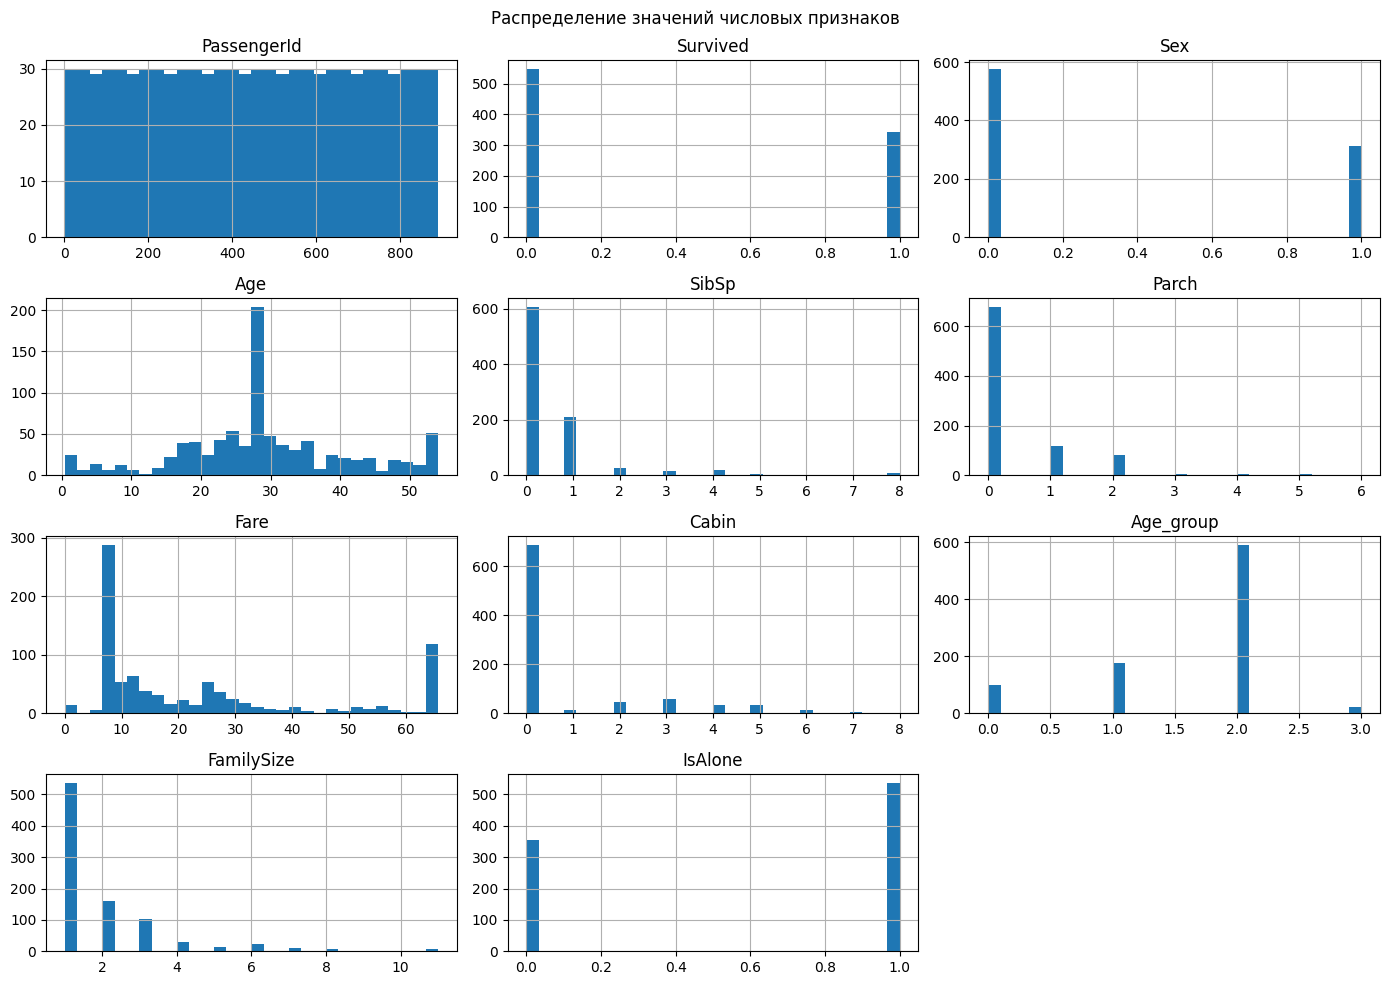

In [ ]:
numeric_columns = train.select_dtypes(include='number').columns

train[numeric_columns].hist(figsize=(14, 10), bins=30)

plt.suptitle('Распределение значений числовых признаков')
plt.tight_layout()
plt.show()

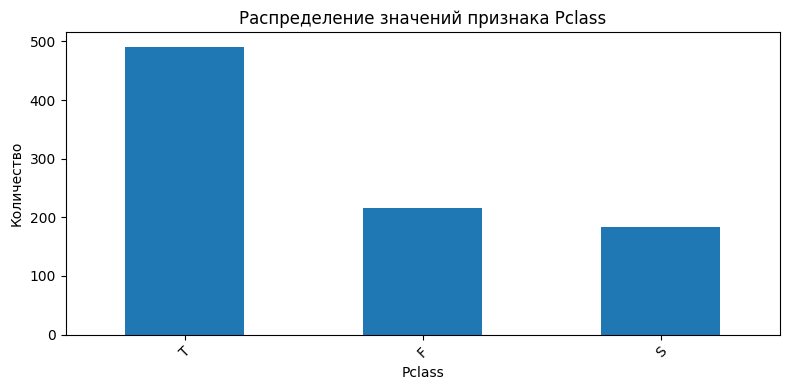

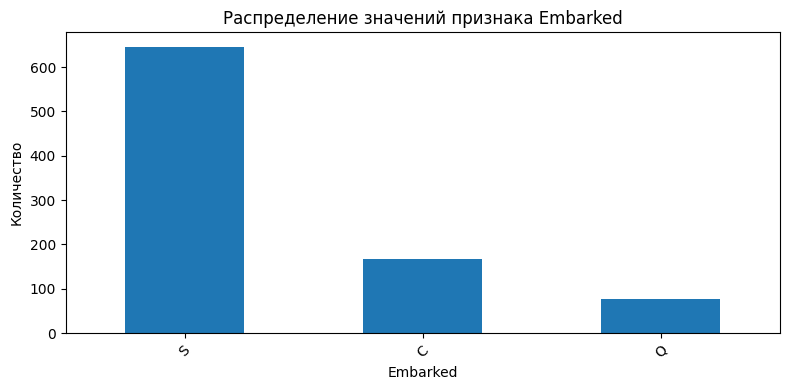

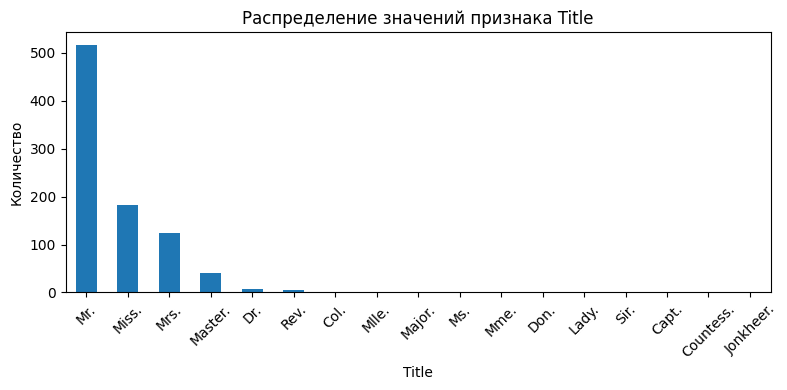

In [ ]:
categorical_columns = train.select_dtypes(include=['object']).columns

categorical_columns = categorical_columns.drop(['Name', 'Ticket'])

for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    train[column].value_counts().plot(kind='bar')

    plt.title(f'Распределение значений признака {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 6.4. Корреляция между новыми признаками

In [ ]:
new_features = [
    'Sex',
    'Cabin',
    'Age_group',
    'FamilySize',
    'IsAlone'
]

correlation_matrix = train[new_features].corr().round(4)

correlation_matrix

,Sex,Cabin,Age_group,FamilySize,IsAlone
Sex,1.0000,0.1435,-0.1242,0.2010,-0.3036
Cabin,0.1435,1.0000,0.0687,-0.0031,-0.1559
Age_group,-0.1242,0.0687,1.0000,-0.3175,0.2591
FamilySize,0.2010,-0.0031,-0.3175,1.0000,-0.6909
IsAlone,-0.3036,-0.1559,0.2591,-0.6909,1.0000


## Авторское/дополнительное: градация Social_rank по следующему принципу:
0 - Обращения по социальному статусу (Mr., Mrs., Miss., Master., Mme., Mlle., Ms.)  
1 - Профессиональные обращения (Dr., Rev.)  
2 - Воинские звания и чины аристократии (Capt., Major., Col., Lady., Sir., Countess., Don., Jonkheer.)

In [ ]:
priority_level = {'Mr.': 0, 'Mrs.': 0, 'Miss.': 0, 'Master.': 0, 'Mme.': 0, 'Mlle.': 0, 'Ms.': 0,
                  'Dr.': 1, 'Rev.': 1,
                  'Capt.': 2, 'Major.': 2, 'Col.': 2, 'Lady.': 2, 'Sir.': 2, 'Countess.': 2, 'Don.': 2, 'Jonkheer.': 2}

In [ ]:
train['Priority_level'] = train['Title'].map(priority_level)

In [ ]:
train.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Title,FamilySize,IsAlone,Priority_level
881,882,0,T,"Markun, Johann",0,33.0,0,0,349257,7.8958,0,S,2,Mr.,1,1,0
882,883,0,T,"Dahlberg, Gerda Ulrika",1,22.0,0,0,7552,10.5167,0,S,1,Miss.,1,1,0
883,884,0,S,"Banfield, Frederick James",0,28.0,0,0,C.A./SOTON 34068,10.5000,0,S,2,Mr.,1,1,0
884,885,0,T,"Sutehall, Henry Jr",0,25.0,0,0,SOTON/OQ 392076,7.0500,0,S,2,Mr.,1,1,0
885,886,0,T,"Rice, William (Margaret Norton)",1,39.0,0,5,382652,29.1250,0,Q,2,Mrs.,6,0,0
886,887,0,S,"Montvila, Juozas",0,27.0,0,0,211536,13.0000,0,S,2,Rev.,1,1,1
887,888,1,F,"Graham, Margaret Edith",1,19.0,0,0,112053,30.0000,2,S,1,Miss.,1,1,0
888,889,0,T,"Johnston, Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,0,S,2,Miss.,4,0,0
889,890,1,F,"Behr, Karl Howell",0,26.0,0,0,111369,30.0000,3,C,2,Mr.,1,1,0
890,891,0,T,"Dooley, Patrick",0,32.0,0,0,370376,7.7500,0,Q,2,Mr.,1,1,0


In [ ]:
train['Priority_level'].unique()

array([0, 2, 1])

In [ ]:
correlation_matrix_exp = train[['Priority_level', 'Survived']].corr().round(4)
correlation_matrix_exp
# Социальный статус не влиял на выживаемость

,Priority_level,Survived
Priority_level,1.0000,0.0032
Survived,0.0032,1.0000
